# F1 vs feature correlations (paper revision)

Per-plant F1 score (from new MLP) vs per-plant mean of 4 key features
(emission, surface albedo NO$_2$ window, sensor zenith angle, wind speed)
for both U.S. and Global datasets.

Reads the per-plant CSVs produced by `9_per_plant_f1_map.ipynb`
(`per_plant_performance_us.csv`, `per_plant_performance_world.csv`).
Make sure that notebook has been run first.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats

plt.rcdefaults()
plt.rcParams.update({
    'figure.dpi': 300, 'savefig.dpi': 300,
    'font.size': 11, 'axes.linewidth': 0.8,
    'pdf.fonttype': 42, 'ps.fonttype': 42,  # TrueType (Type 42) embedding -- avoids Type-3 viewer warnings
})

nimbus_path = None
for _p in fm.findSystemFonts():
    _pl = _p.lower()
    if ('nimbusroman' in _pl or 'nimbus_roman' in _pl) \
            and 'bold' not in _pl and 'italic' not in _pl and 'oblique' not in _pl:
        nimbus_path = _p; break
if nimbus_path:
    fm.fontManager.addfont(nimbus_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=nimbus_path).get_name()
    print('Registered:', plt.rcParams['font.family'])

colors = {'us': '#FF6B6B', 'global': '#4ECDC4', 'text': '#2E3440'}

# Per-plant F1 CSVs produced by 9_per_plant_f1_map.ipynb
PERF_FILES = {
    'US':     Path('/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/per_plant_performance_us.csv'),
    'Global': Path('/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/per_plant_performance_world.csv'),
}
OBS_FILES = {
    'US':     Path('/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv'),
    'Global': Path('/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/Run_100m_20260428/updated_tropomi_emissions_full_variables_with_fuel_100mlabel.csv'),
}
OUT_DIR = '/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures'
os.makedirs(OUT_DIR, exist_ok=True)

FEATURES_TO_ANALYZE = [
    'Annual/Hourly NOx Emission',
    'surface_albedo_nitrogendioxide_window',
    'sensor_zenith_angle',
    'wind_speed',
]
FEATURE_DISPLAY_NAMES = {
    'Annual/Hourly NOx Emission':            'Annual/Hourly NOx Emission',
    'surface_albedo_nitrogendioxide_window': r'Surface Albedo (NO$_2$ Window)',
    'sensor_zenith_angle':                   'Sensor Zenith Angle (\u00b0)',
    'wind_speed':                            'Wind Speed (m/s)',
}

Registered: ['Nimbus Roman']


In [2]:
# ─── Helpers ─────────────────────────────────────────────────────────
def resolve_emission_column(df):
    for c in ('NOx Mass (lbs)', 'hourly_emission_rate', 'annual_nox_emission', 'nox_emis_ty'):
        if c in df.columns: return c
    raise KeyError('No emission column found')

def resolve_feature_column(df, feat):
    if feat in df.columns: return feat
    aliases = {
        'wind_speed': ['wind_speed', '10m_wind_speed', 'wind_speed_10m'],
        'surface_albedo_nitrogendioxide_window': ['surface_albedo_nitrogendioxide_window'],
        'sensor_zenith_angle': ['sensor_zenith_angle'],
    }
    for c in aliases.get(feat, []):
        if c in df.columns: return c
    raise KeyError(f'No column for {feat!r}')

def calculate_plant_means(obs_df, location_col='location'):
    cols = []
    for f in FEATURES_TO_ANALYZE:
        try:
            col = resolve_emission_column(obs_df) if f == 'Annual/Hourly NOx Emission' \
                  else resolve_feature_column(obs_df, f)
            cols.append(col)
        except KeyError:
            continue
    return obs_df.groupby(location_col)[cols].mean().reset_index()

In [3]:
# ─── Load and merge ──────────────────────────────────────────────────
results = {}
for ds in ['US', 'Global']:
    print(f'--- {ds} ---')
    perf = pd.read_csv(PERF_FILES[ds])
    obs  = pd.read_csv(OBS_FILES[ds]).dropna()
    print(f'  perf rows = {len(perf)}, obs rows = {len(obs)}')

    # Total positive count per plant across the modeling subset (all obs that
    # would feed train/val/test, not test only). This matches the caption's
    # "at least 3 positive observations" criterion.
    obs_in_set = obs[obs['location'].isin(perf['location'])]
    pos_total = (obs_in_set[obs_in_set['plume_label'] == 1]
                 .groupby('location').size()
                 .rename('pos_total'))

    means = calculate_plant_means(obs, 'location')
    merged = pd.merge(perf, means, on='location', how='inner')
    merged = merged.merge(pos_total, on='location', how='left')
    merged['pos_total'] = merged['pos_total'].fillna(0).astype(int)
    print(f'  merged: {len(merged)} plants  (pos_total>=3: {(merged.pos_total>=3).sum()})')
    results[ds] = merged

--- US ---


  perf rows = 171, obs rows = 501720
  merged: 171 plants  (pos_total>=3: 171)
--- Global ---


  perf rows = 1065, obs rows = 875580


  merged: 1065 plants  (pos_total>=3: 1062)


In [4]:
# ─── Scatter plot helper ─────────────────────────────────────────────
def scatter_with_fit(ax, x, y, title, xlabel, ylabel, color):
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    if len(x) < 3:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(title, fontweight='bold'); return
    ax.scatter(x, y, alpha=0.6, s=50, color=color, edgecolors='white', linewidth=0.5)
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xs = np.array([x.min(), x.max()])
    ax.plot(xs, slope * xs + intercept, '--', color='#2E3440', linewidth=2, alpha=0.8)
    ax.text(0.85, 0.15, f'R\u00b2 = {r**2:.3f}\nn = {len(x)}',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.set_xlabel(xlabel, fontsize=11, fontweight='600')
    ax.set_ylabel(ylabel, fontsize=11, fontweight='600')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.set_ylim(0, 1.05)        # F1 is bounded in [0, 1]; pin axis to keep regression-fit overshoots out of view
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

Saved: /net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/f1_score_feature_correlations.pdf


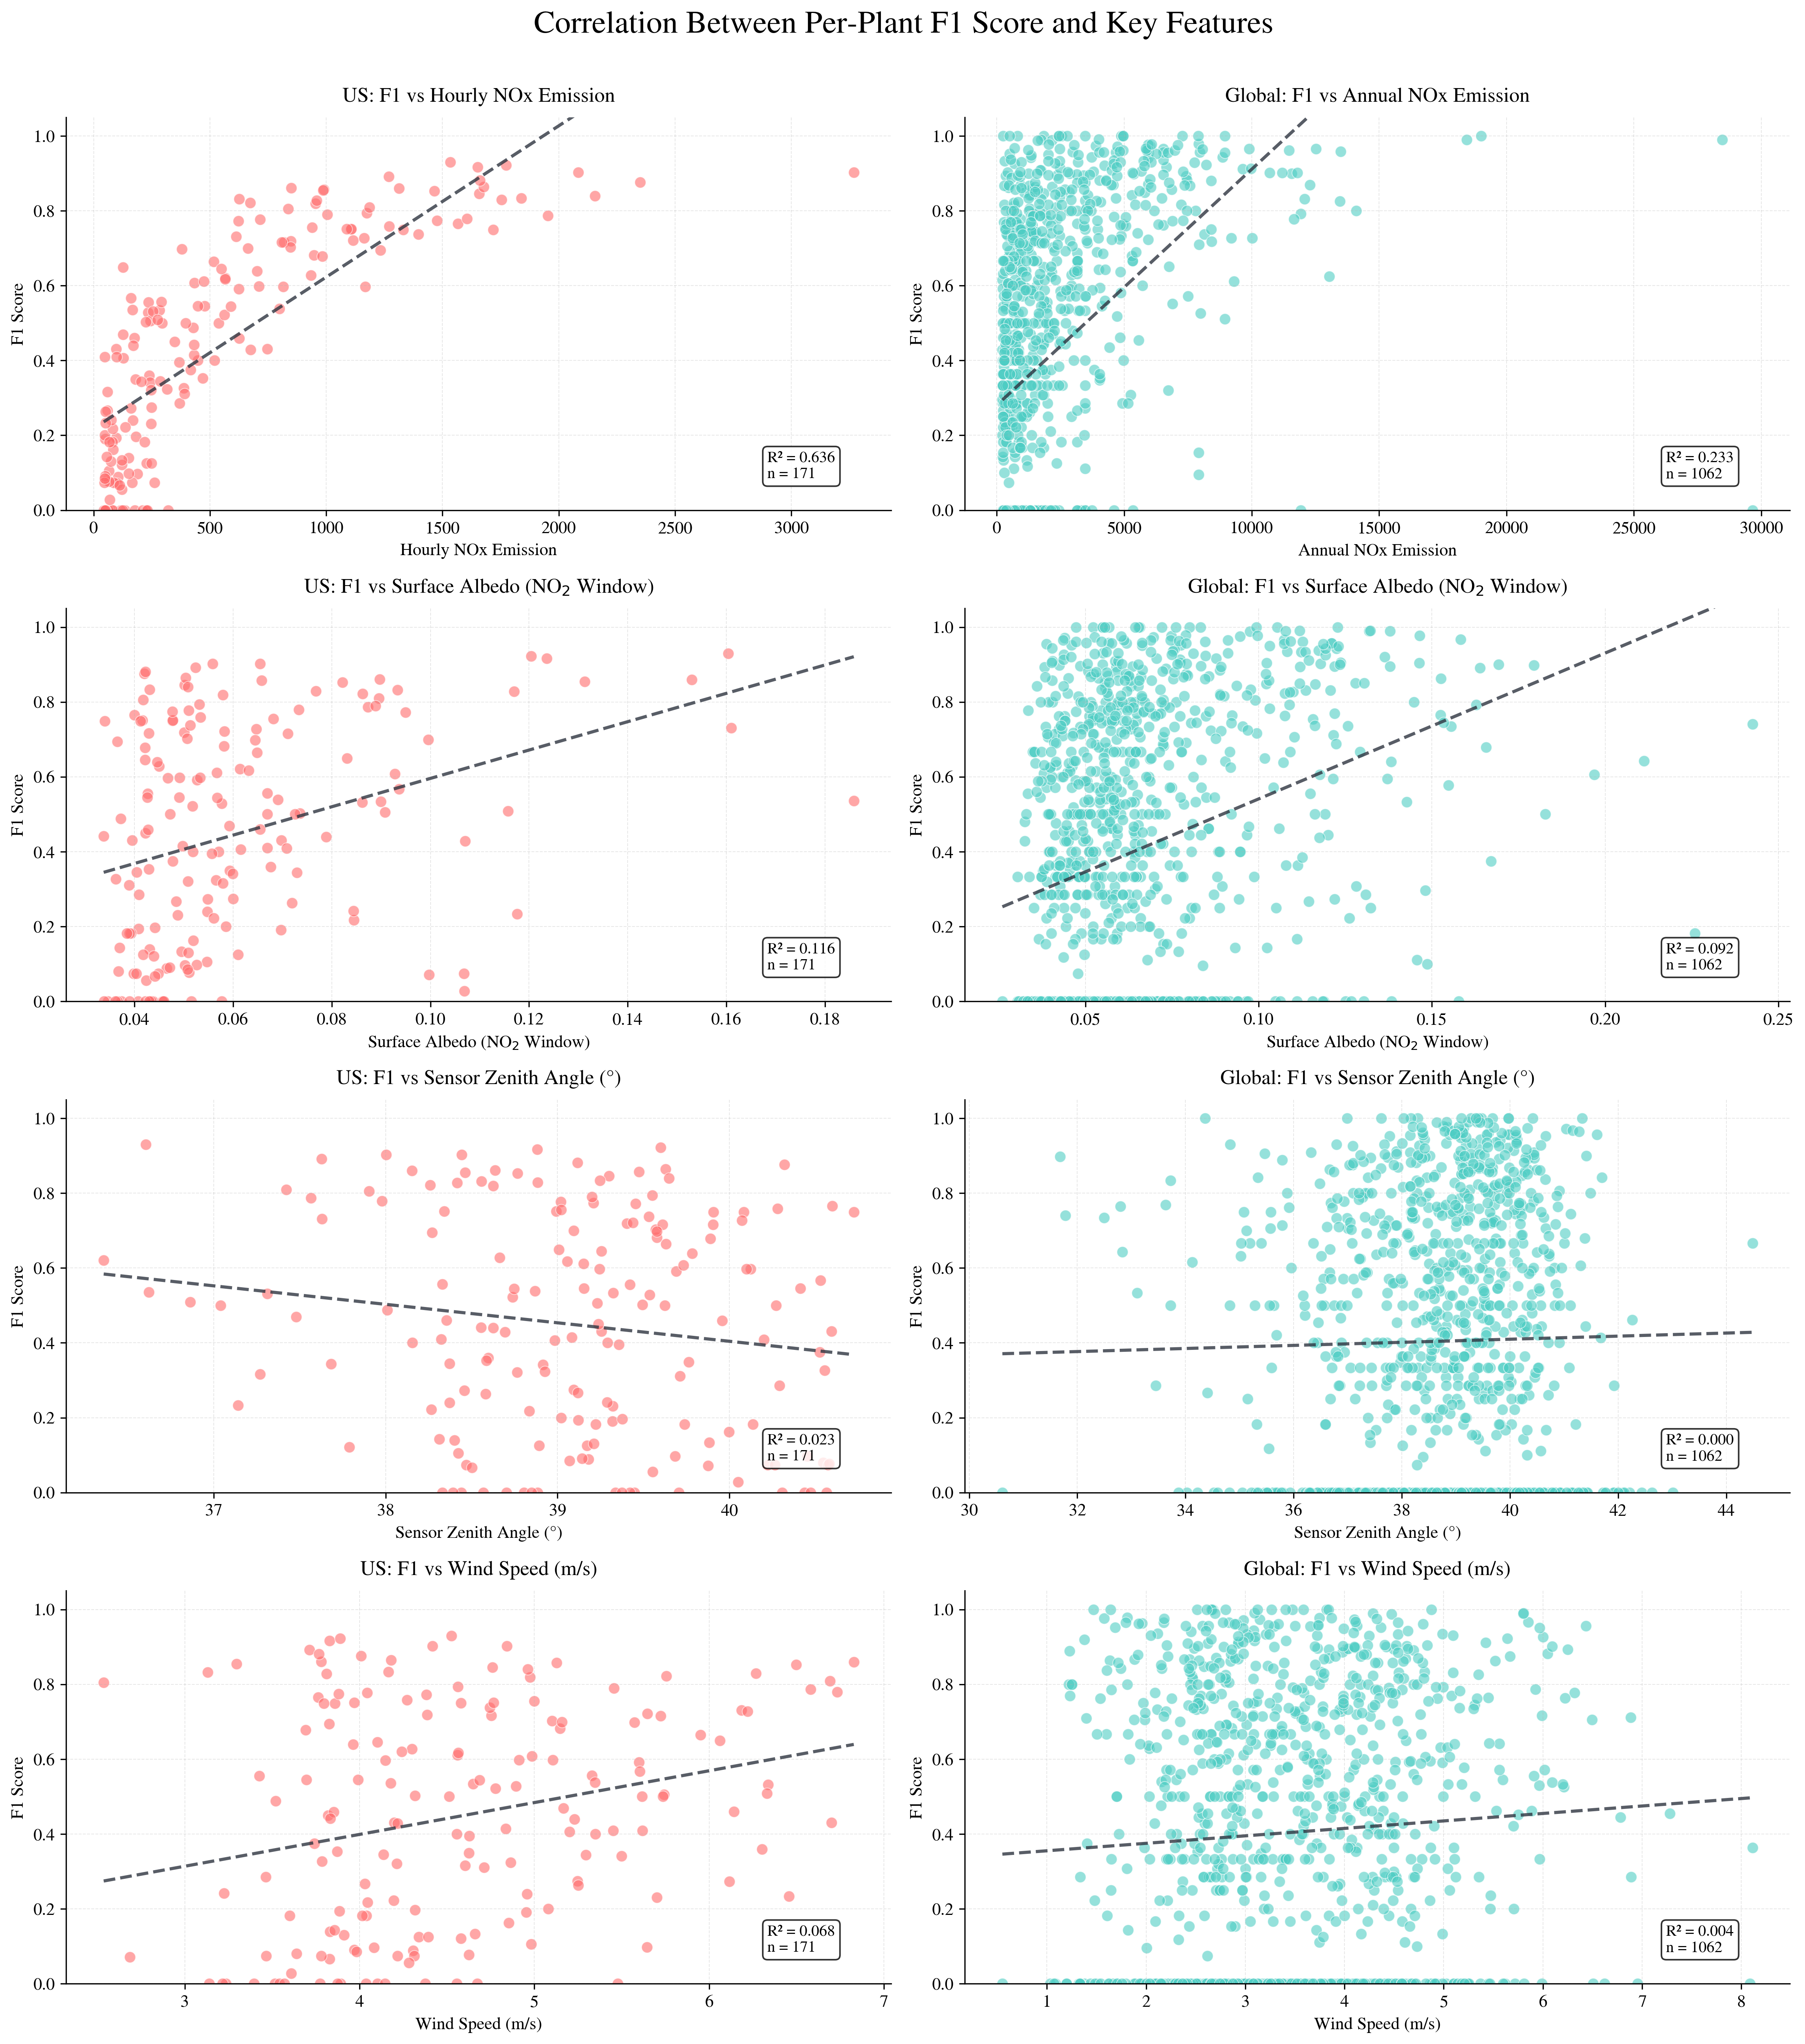


=== Pearson R (F1 vs feature mean) ===

Annual/Hourly NOx Emission
  US      : R=+0.7976  R²=0.6362  n=171
  Global  : R=+0.4823  R²=0.2326  n=1062

Surface Albedo (NO$_2$ Window)
  US      : R=+0.3407  R²=0.1161  n=171
  Global  : R=+0.3040  R²=0.0924  n=1062

Sensor Zenith Angle (°)
  US      : R=-0.1511  R²=0.0228  n=171
  Global  : R=+0.0187  R²=0.0004  n=1062

Wind Speed (m/s)
  US      : R=+0.2607  R²=0.0679  n=171
  Global  : R=+0.0619  R²=0.0038  n=1062


In [5]:
# ─── Render 4 features × 2 datasets grid ─────────────────────────────
n = len(FEATURES_TO_ANALYZE)
fig, axes = plt.subplots(n, 2, figsize=(16, 4.5 * n))
if n == 1: axes = axes.reshape(1, -1)

for i, feat in enumerate(FEATURES_TO_ANALYZE):
    for j, ds in enumerate(['US', 'Global']):
        ax = axes[i, j]
        merged = results[ds]
        # restrict to plants with >= 3 positive observations in the
        # modeling subset (matches caption: 1065 -> 1062 for Global)
        merged = merged[merged['pos_total'] >= 3]
        try:
            col = resolve_emission_column(merged) if feat == 'Annual/Hourly NOx Emission' \
                  else resolve_feature_column(merged, feat)
        except KeyError:
            ax.text(0.5, 0.5, f"'{feat}' missing in {ds}", ha='center',
                    va='center', transform=ax.transAxes)
            ax.axis('off'); continue

        x = merged[col].values
        y = merged['f1'].values

        if feat == 'Annual/Hourly NOx Emission':
            display = 'Hourly NOx Emission' if ds == 'US' else 'Annual NOx Emission'
        else:
            display = FEATURE_DISPLAY_NAMES.get(feat, feat)

        scatter_with_fit(ax, x, y,
                          title=f'{ds}: F1 vs {display}',
                          xlabel=display, ylabel='F1 Score',
                          color=colors['us'] if ds == 'US' else colors['global'])

fig.suptitle('Correlation Between Per-Plant F1 Score and Key Features',
             fontsize=20, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])

out_pdf = os.path.join(OUT_DIR, 'f1_score_feature_correlations.pdf')
out_png = os.path.join(OUT_DIR, 'f1_score_feature_correlations.png')
plt.savefig(out_pdf, dpi=300, bbox_inches='tight')
plt.savefig(out_png, dpi=300, bbox_inches='tight')
print(f'Saved: {out_pdf}')
plt.show()

# Pearson R summary
print('\n=== Pearson R (F1 vs feature mean) ===')
for feat in FEATURES_TO_ANALYZE:
    print(f'\n{FEATURE_DISPLAY_NAMES.get(feat, feat)}')
    for ds in ['US', 'Global']:
        merged = results[ds]
        merged = merged[merged['pos_total'] >= 3]
        try:
            col = resolve_emission_column(merged) if feat == 'Annual/Hourly NOx Emission' \
                  else resolve_feature_column(merged, feat)
        except KeyError:
            continue
        x = merged[col].values; y = merged['f1'].values
        m = ~(np.isnan(x) | np.isnan(y))
        if m.sum() < 3: continue
        r = np.corrcoef(x[m], y[m])[0, 1]
        print(f'  {ds:8s}: R={r:+.4f}  R\u00b2={r**2:.4f}  n={m.sum()}')